In [1]:
import pandas as pd
import numpy as np

### MERGED ACTIVE AND INACTIVE DATASETS

In [2]:
active_df = pd.read_csv("active.csv")

inactive_df = pd.read_csv("inactive.csv")

In [3]:
print(active_df.shape)
print(inactive_df.shape)

active_df.head()

(519, 2)
(410, 2)


,SMILES,IC50
0,COC1=CC(=C(C=C1)CN(CCC(C2=CC=CC=C2)C3=CC=CC=C3...,2.0
1,C=CCN(C1CCCCC1)C(=O)C2=CC3=C(C=C2)N(C(=N3)NC(=...,230.0
2,CN(C1CCCCC1)C(=O)C2=CC3=C(C=C2)N(C(=N3)NC(=O)C...,250.0
3,CNC(=O)CCN1C2=C(C=C(C=C2)C(=O)N(C)C3CCCCC3)N=C...,160.0
4,CN(C1CCCCC1)C(=O)C2=CC3=C(C=C2)N(C(=N3)NC(=O)C...,92.0


In [4]:
print(active_df.columns)

print(inactive_df.columns)

Index(['SMILES', 'IC50'], dtype='object')
Index(['Smiles', 'IC50'], dtype='object')


In [5]:
print(active_df.dtypes)

print(inactive_df.dtypes)

SMILES     object
IC50      float64
dtype: object
Smiles     object
IC50      float64
dtype: object


In [6]:
inactive_df.rename(
    columns={"Smiles":"SMILES"},
    inplace=True
)

In [7]:
print(active_df.columns)

print(inactive_df.columns)

Index(['SMILES', 'IC50'], dtype='object')
Index(['SMILES', 'IC50'], dtype='object')


### CALCULATE pIC50

In [8]:
import numpy as np

active_df["pIC50"] = -np.log10(
    active_df["IC50"] * 1e-9
)

inactive_df["pIC50"] = -np.log10(
    inactive_df["IC50"] * 1e-9
)

In [9]:
active_df.head()

inactive_df.head()

,SMILES,IC50,pIC50
0,CN1C(=CC=N1)CNC(=O)C2=CC3=C(C=C2)C=C(N3)C4=NNC...,1000.0,6.0
1,CN(C)CCC1=CC2=C(C=C1)C=C(N2)C3=NNC4=C3N=CC=C4,1000.0,6.0
2,COC1=CC2=C(C=C1)C=C(N2)C3=NNC4=C3C=C(C=C4)NC(=...,1000.0,6.0
3,CC(=O)N1CCN(CC1)C(=O)C2=CC=CC(=C2)CSC3=CN=C(S3...,1000.0,6.0
4,CN(C1=CC2=C(C=C1)N(C(=N2)NC(=O)C3=CC=CC(=C3)C4...,1000.0,6.0


### GAVE ACTIVITY VALUES active:1 and inactive:0

In [10]:
active_df["Activity"] = 1

inactive_df["Activity"] = 0

In [11]:
print(active_df["Activity"].value_counts())

print(inactive_df["Activity"].value_counts())

Activity
1    519
Name: count, dtype: int64
Activity
0    410
Name: count, dtype: int64


In [12]:
final_df = pd.concat(
    [active_df, inactive_df],
    ignore_index=True
)

In [13]:
print(final_df.shape)

final_df.head()

(929, 4)


,SMILES,IC50,pIC50,Activity
0,COC1=CC(=C(C=C1)CN(CCC(C2=CC=CC=C2)C3=CC=CC=C3...,2.0,8.698970,1
1,C=CCN(C1CCCCC1)C(=O)C2=CC3=C(C=C2)N(C(=N3)NC(=...,230.0,6.638272,1
2,CN(C1CCCCC1)C(=O)C2=CC3=C(C=C2)N(C(=N3)NC(=O)C...,250.0,6.602060,1
3,CNC(=O)CCN1C2=C(C=C(C=C2)C(=O)N(C)C3CCCCC3)N=C...,160.0,6.795880,1
4,CN(C1CCCCC1)C(=O)C2=CC3=C(C=C2)N(C(=N3)NC(=O)C...,92.0,7.036212,1


In [14]:
final_df.to_csv(
    "ITK_combined_dataset.csv",
    index=False
)

print("CSV saved successfully")

CSV saved successfully


### Calculate the 8 descriptors

In [15]:
from rdkit import Chem
from rdkit.Chem import Descriptors

In [16]:
def calculate_descriptors(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return [None]*8

    return [

        Descriptors.MolWt(mol),

        Descriptors.MolLogP(mol),

        Descriptors.NumHDonors(mol),

        Descriptors.NumHAcceptors(mol),

        Descriptors.TPSA(mol),

        Descriptors.NumRotatableBonds(mol),

        Descriptors.RingCount(mol),

        Descriptors.HeavyAtomCount(mol)

    ]

In [17]:
descriptor_names = [

    "MolWt",

    "LogP",

    "HDonors",

    "HAcceptors",

    "TPSA",

    "RotatableBonds",

    "RingCount",

    "HeavyAtomCount"

]

In [18]:
descriptor_df = final_df["SMILES"] \
                .apply(calculate_descriptors) \
                .apply(pd.Series)

descriptor_df.columns = descriptor_names

In [19]:
descriptor_df.head()

,MolWt,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,RingCount,HeavyAtomCount
0,581.738,6.9077,1.0,7.0,76.83,14.0,5.0,42.0
1,552.473,4.8874,2.0,4.0,110.32,9.0,4.0,36.0
2,465.529,3.7078,2.0,4.0,110.32,7.0,4.0,34.0
3,467.595,3.8909,2.0,5.0,96.33,7.0,4.0,33.0
4,440.569,4.1372,2.0,5.0,87.46,7.0,4.0,31.0


In [20]:
final_desc_df = pd.concat(
    [final_df, descriptor_df],
    axis=1
)

In [21]:
print(final_desc_df.shape)

(929, 12)


In [22]:
final_desc_df.head()

,SMILES,IC50,pIC50,Activity,MolWt,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,RingCount,HeavyAtomCount
0,COC1=CC(=C(C=C1)CN(CCC(C2=CC=CC=C2)C3=CC=CC=C3...,2.0,8.698970,1,581.738,6.9077,1.0,7.0,76.83,14.0,5.0,42.0
1,C=CCN(C1CCCCC1)C(=O)C2=CC3=C(C=C2)N(C(=N3)NC(=...,230.0,6.638272,1,552.473,4.8874,2.0,4.0,110.32,9.0,4.0,36.0
2,CN(C1CCCCC1)C(=O)C2=CC3=C(C=C2)N(C(=N3)NC(=O)C...,250.0,6.602060,1,465.529,3.7078,2.0,4.0,110.32,7.0,4.0,34.0
3,CNC(=O)CCN1C2=C(C=C(C=C2)C(=O)N(C)C3CCCCC3)N=C...,160.0,6.795880,1,467.595,3.8909,2.0,5.0,96.33,7.0,4.0,33.0
4,CN(C1CCCCC1)C(=O)C2=CC3=C(C=C2)N(C(=N3)NC(=O)C...,92.0,7.036212,1,440.569,4.1372,2.0,5.0,87.46,7.0,4.0,31.0


In [23]:
final_desc_df.to_csv(

    "ITK_combined_8_descriptors.csv",

    index=False

)

print("CSV saved successfully")

CSV saved successfully


### Create SWISS ADME sheet with GI and BBB values

In [24]:
adme_df = pd.read_csv("Adme.csv")

print(adme_df.shape)

adme_df.head()

(929, 3)


,SMILES,GI absorption,BBB permeant
0,COC1=CC(=C(C=C1)CN(CCC(C2=CC=CC=C2)C3=CC=CC=C3...,Low,No
1,C=CCN(C1CCCCC1)C(=O)C2=CC3=C(C=C2)N(C(=N3)NC(=...,High,No
2,CN(C1CCCCC1)C(=O)C2=CC3=C(C=C2)N(C(=N3)NC(=O)C...,High,No
3,CNC(=O)CCN1C2=C(C=C(C=C2)C(=O)N(C)C3CCCCC3)N=C...,High,No
4,CN(C1CCCCC1)C(=O)C2=CC3=C(C=C2)N(C(=N3)NC(=O)C...,High,No


In [27]:
print(final_desc_df.shape)

print(adme_df.shape)

(929, 12)
(929, 3)


### REMOVE DUPLICATES 

In [37]:
adme_unique = adme_df.drop_duplicates(
    subset="SMILES"
)

print(adme_unique.shape)

(700, 3)


In [38]:
merged_df = pd.merge(

    final_desc_df,

    adme_unique,

    on="SMILES",

    how="left"

)

print(merged_df.shape)

(929, 14)


### CHECK FOR MISSING VALUES

In [39]:
print(merged_df.isnull().sum())

SMILES            0
IC50              0
pIC50             0
Activity          0
MolWt             0
LogP              0
HDonors           0
HAcceptors        0
TPSA              0
RotatableBonds    0
RingCount         0
HeavyAtomCount    0
GI absorption     0
BBB permeant      0
dtype: int64


In [41]:
print(

merged_df[
    ["GI absorption",
     "BBB permeant"]

].isnull().sum()

)

GI absorption    0
BBB permeant     0
dtype: int64


### CONVERT GI AND BBB INTO NUMERIC 

In [42]:
merged_df["GI absorption"] = merged_df["GI absorption"].replace({

    "High":1,

    "Low":0

})

C:\Users\KIIT\AppData\Local\Temp\ipykernel_39348\1654034124.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_df["GI absorption"] = merged_df["GI absorption"].replace({


In [43]:
merged_df["BBB permeant"] = merged_df["BBB permeant"].replace({

    "Yes":1,

    "No":0

})

C:\Users\KIIT\AppData\Local\Temp\ipykernel_39348\1057432153.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_df["BBB permeant"] = merged_df["BBB permeant"].replace({


In [44]:
merged_df[

    ["GI absorption",

     "BBB permeant"]

].head()

,GI absorption,BBB permeant
0,0,0
1,1,0
2,1,0
3,1,0
4,1,0


### BOXPLOT 

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

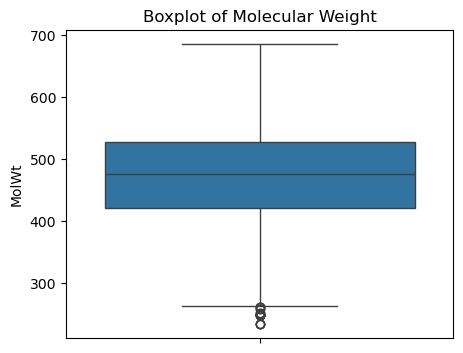

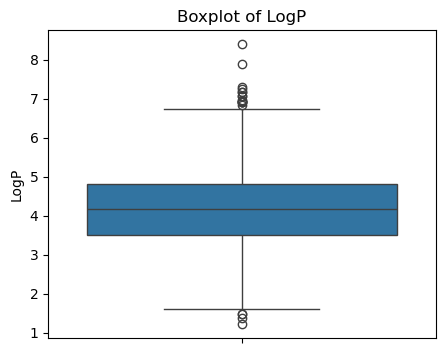

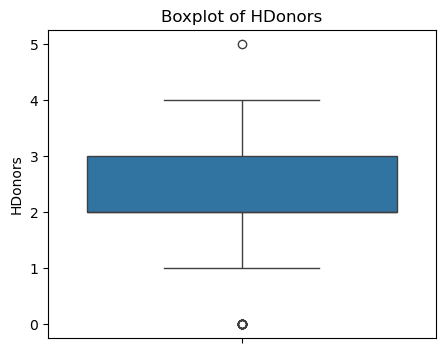

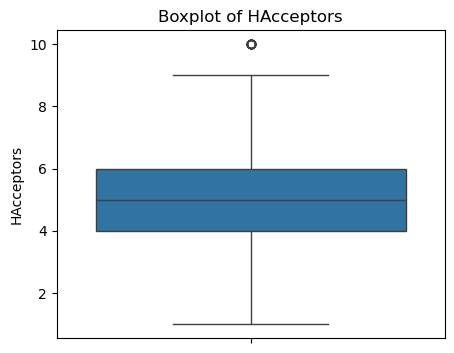

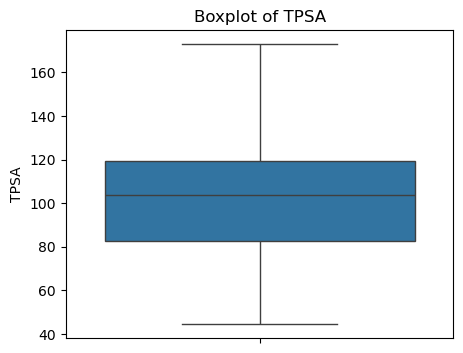

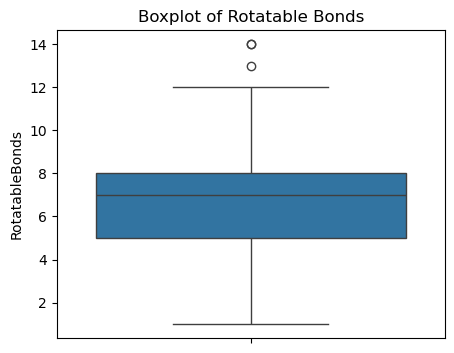

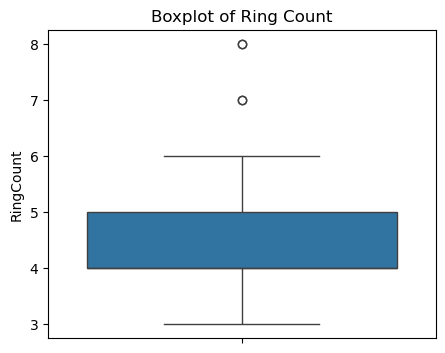

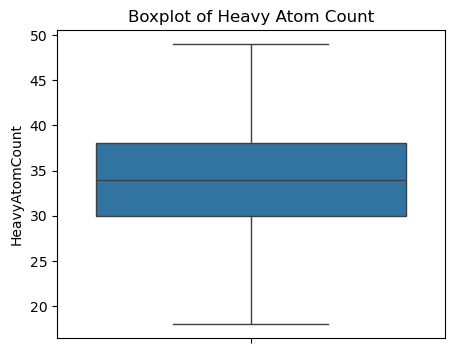

In [46]:
## MolWt
plt.figure(figsize=(5,4))

sns.boxplot(y=merged_df["MolWt"])

plt.title("Boxplot of Molecular Weight")

plt.show()

## LogP
plt.figure(figsize=(5,4))

sns.boxplot(y=merged_df["LogP"])

plt.title("Boxplot of LogP")

plt.show()

## HDonors
plt.figure(figsize=(5,4))

sns.boxplot(y=merged_df["HDonors"])

plt.title("Boxplot of HDonors")

plt.show()

## HAcceptors
plt.figure(figsize=(5,4))

sns.boxplot(y=merged_df["HAcceptors"])

plt.title("Boxplot of HAcceptors")

plt.show()

##TPSA
plt.figure(figsize=(5,4))

sns.boxplot(y=merged_df["TPSA"])

plt.title("Boxplot of TPSA")

plt.show()

## Rotatable Bonds
plt.figure(figsize=(5,4))

sns.boxplot(y=merged_df["RotatableBonds"])

plt.title("Boxplot of Rotatable Bonds")

plt.show()

##Ring Count
plt.figure(figsize=(5,4))

sns.boxplot(y=merged_df["RingCount"])

plt.title("Boxplot of Ring Count")

plt.show()

## Heavy Atom Counts


### EDA 

In [47]:
merged_df.describe()

,IC50,pIC50,Activity,MolWt,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,RingCount,HeavyAtomCount,GI absorption,BBB permeant
count,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000
mean,3200.555608,6.555508,0.558665,466.146363,4.226631,2.195910,5.305705,102.226006,6.416577,4.511302,33.705059,0.566200,0.142088
std,8088.082925,1.164642,0.496814,90.836028,1.060954,0.781207,1.912183,25.680282,2.301092,0.693358,6.188245,0.495865,0.349329
min,0.200000,4.080922,0.000000,233.274000,1.215000,0.000000,1.000000,44.470000,1.000000,3.000000,18.000000,0.000000,0.000000
25%,35.000000,5.634512,0.000000,421.501000,3.502100,2.000000,4.000000,82.800000,5.000000,4.000000,30.000000,0.000000,0.000000
50%,260.000000,6.585027,1.000000,475.618000,4.155500,2.000000,5.000000,103.530000,7.000000,4.000000,34.000000,1.000000,0.000000
75%,2320.000000,7.455932,1.000000,527.673000,4.820420,3.000000,6.000000,119.550000,8.000000,5.000000,38.000000,1.000000,0.000000
max,83000.000000,9.698970,1.000000,685.842000,8.396400,5.000000,10.000000,173.020000,14.000000,8.000000,49.000000,1.000000,1.000000


### REMOVE DUPLICATES

In [48]:
print(merged_df["Activity"].value_counts())

Activity
1    519
0    410
Name: count, dtype: int64


In [49]:
print(
merged_df.duplicated(
subset=["SMILES","IC50"]
).sum()
)

14


In [50]:
merged_df = merged_df.drop_duplicates(

subset=["SMILES","IC50"],

keep="first"

)

In [51]:
print(merged_df.shape)

(915, 14)


In [52]:
print(

merged_df.duplicated(

subset=["SMILES","IC50"]

).sum()

)

0


In [53]:
merged_df.to_csv(

"ITK_final_cleaned.csv",

index=False

)

print("CSV saved successfully")

CSV saved successfully


In [54]:
merged_df.to_csv(

"ITK_final_cleaned.csv",

index=False

)

print("CSV saved successfully")

CSV saved successfully


### ACTIVITY DISTRIBUTION

In [55]:
print(merged_df["Activity"].value_counts())

Activity
1    514
0    401
Name: count, dtype: int64


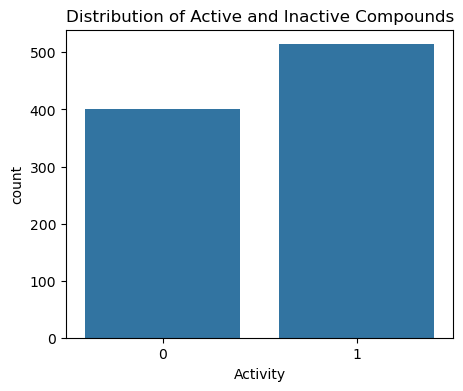

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.countplot(
    x="Activity",
    data=merged_df
)

plt.title("Distribution of Active and Inactive Compounds")

plt.show()

### DISTRIBUTION OF pIC50

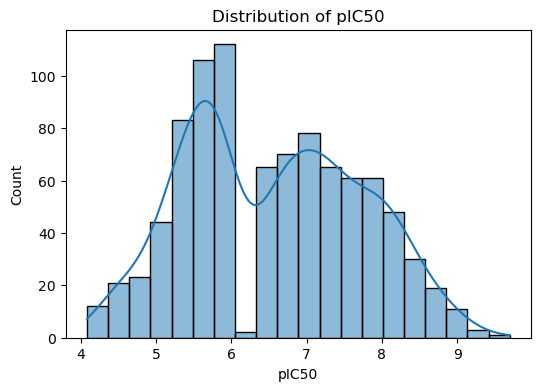

In [57]:
plt.figure(figsize=(6,4))

sns.histplot(
    merged_df["pIC50"],
    bins=20,
    kde=True
)

plt.title("Distribution of pIC50")

plt.xlabel("pIC50")

plt.show()

### CORRELATION HEATMAP

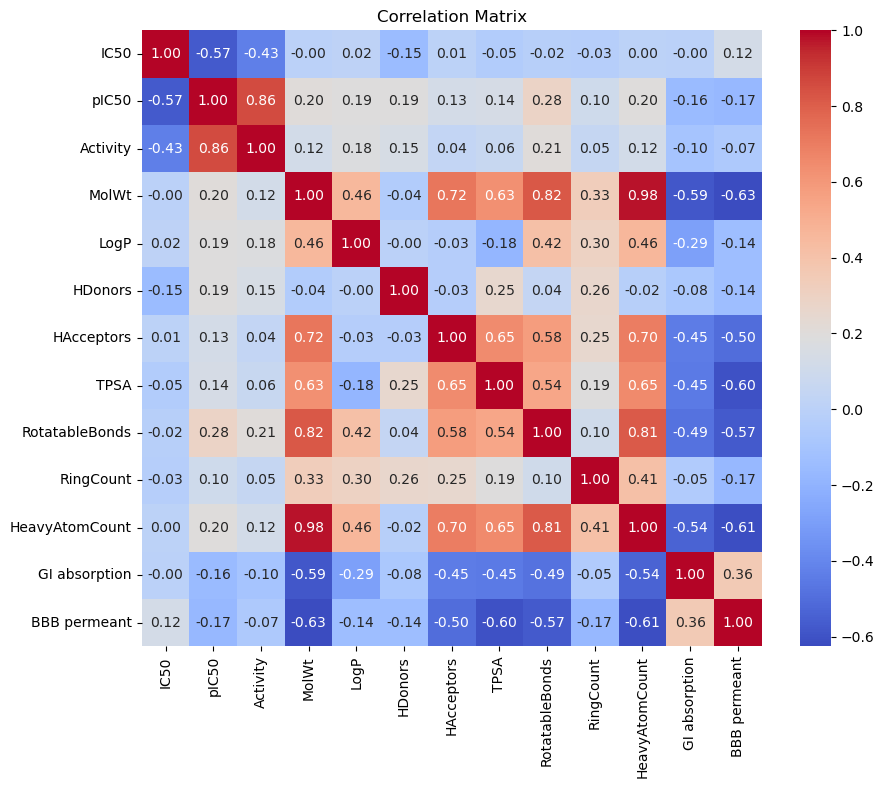

In [58]:
plt.figure(figsize=(10,8))

corr = merged_df.corr(numeric_only=True)

sns.heatmap(

corr,

annot=True,

cmap="coolwarm",

fmt=".2f"

)

plt.title("Correlation Matrix")

plt.show()

In [59]:
X = merged_df[

[
"MolWt",

"LogP",

"HDonors",

"HAcceptors",

"TPSA",

"RotatableBonds",

"RingCount",

"HeavyAtomCount",

"GI absorption",

"BBB permeant"

]

]

y = merged_df["Activity"]

In [60]:
print(X.shape)

print(y.shape)

(915, 10)
(915,)


### TRAIN AND TEST 

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(732, 10)
(183, 10)
(732,)
(183,)


### SCALING

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)

print(X_test_scaled.shape)

(732, 10)
(183, 10)


In [64]:
print(X_train_scaled.shape)

print(X_test_scaled.shape)

(732, 10)
(183, 10)


### LOGISTIC REGRESSION

In [65]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (

    accuracy_score,

    confusion_matrix,

    classification_report

)

# Create model

log_model = LogisticRegression(

    random_state=42

)

# Train

log_model.fit(

    X_train_scaled,

    y_train

)

# Predict

y_pred_log = log_model.predict(

    X_test_scaled

)

# Results

print("Accuracy :",

      accuracy_score(

          y_test,

          y_pred_log

      ))

print("\nConfusion Matrix")

print(

confusion_matrix(

y_test,

y_pred_log

)

)

print("\nClassification Report")

print(

classification_report(

y_test,

y_pred_log

)

)

Accuracy : 0.6557377049180327

Confusion Matrix
[[39 41]
 [22 81]]

Classification Report
              precision    recall  f1-score   support

           0       0.64      0.49      0.55        80
           1       0.66      0.79      0.72       103

    accuracy                           0.66       183
   macro avg       0.65      0.64      0.64       183
weighted avg       0.65      0.66      0.65       183



### SVC

In [66]:
from sklearn.svm import SVC

svc_model = SVC(

    kernel="rbf",

    random_state=42

)

svc_model.fit(

    X_train_scaled,

    y_train

)

y_pred_svc = svc_model.predict(

    X_test_scaled

)

print("Accuracy :",

accuracy_score(

y_test,

y_pred_svc

))

print(confusion_matrix(

y_test,

y_pred_svc

))

print(classification_report(

y_test,

y_pred_svc

))

Accuracy : 0.6939890710382514
[[34 46]
 [10 93]]
              precision    recall  f1-score   support

           0       0.77      0.42      0.55        80
           1       0.67      0.90      0.77       103

    accuracy                           0.69       183
   macro avg       0.72      0.66      0.66       183
weighted avg       0.71      0.69      0.67       183



### KNN CLASSIFIER

In [67]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(

    n_neighbors=5

)

knn_model.fit(

    X_train_scaled,

    y_train

)

y_pred_knn = knn_model.predict(

    X_test_scaled

)

print("Accuracy :",

accuracy_score(

y_test,

y_pred_knn

))

print(confusion_matrix(

y_test,

y_pred_knn

))

print(classification_report(

y_test,

y_pred_knn

))

Accuracy : 0.644808743169399
[[43 37]
 [28 75]]
              precision    recall  f1-score   support

           0       0.61      0.54      0.57        80
           1       0.67      0.73      0.70       103

    accuracy                           0.64       183
   macro avg       0.64      0.63      0.63       183
weighted avg       0.64      0.64      0.64       183



### XGBOOST

In [68]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(

    random_state=42,

    eval_metric='logloss'

)

xgb_model.fit(

    X_train,

    y_train

)

y_pred_xgb = xgb_model.predict(

    X_test

)

print("Accuracy :",

accuracy_score(

y_test,

y_pred_xgb

))

print(confusion_matrix(

y_test,

y_pred_xgb

))

print(classification_report(

y_test,

y_pred_xgb

))

Accuracy : 0.6229508196721312
[[39 41]
 [28 75]]
              precision    recall  f1-score   support

           0       0.58      0.49      0.53        80
           1       0.65      0.73      0.68       103

    accuracy                           0.62       183
   macro avg       0.61      0.61      0.61       183
weighted avg       0.62      0.62      0.62       183



### SCREENING

In [309]:
import pandas as pd

screening_df = pd.read_csv("MERGED_BTK_DATASET.csv")

print(screening_df.shape)
screening_df.head()

(17016, 5)


,Compound_Identifier,Canonical_SMILES,IC50_nM,is_inhibitor,Source
0,LQCDFSKEXZSBSK-UHFFFAOYSA-N,C=CC(=O)Nc1ccccc1C1CCNc2c(C(N)=O)c(-c3ccc(Cl)c...,7.30,1,ChEMBL
1,XOUHDJBTWKUDSH-PXDATVDWSA-N,CC1C(N2CCN(C)C2=O)CCCN1c1cnc(C(N)=O)c(Nc2ccc(C...,10.00,1,ChEMBL
2,WHRCWROQSJHEBV-UHFFFAOYSA-N,Cc1c(NC(=O)c2ccc(C(C)(C)C)cc2)cccc1-c1cc(Nc2cc...,19.95,1,ChEMBL
3,OXVXVYNMDOKNGH-DTSLEXBRSA-N,C=CC(=O)N1CCC2(CC(n3c(NC(=O)c4ccc(-c5ccnc6[nH]...,1.21,1,ChEMBL
4,XTLFVWOWCQDPIH-UHFFFAOYSA-N,C=Cc1cccc(Cc2c(F)cc(C(N)=O)c3[nH]c(C)c(C)c23)n1,11.00,1,ChEMBL


In [310]:
### WE keep only the required columns 
screening_df = screening_df[
    ["Compound_Identifier", "Canonical_SMILES"]
]

screening_df = screening_df.rename(
    columns={"Canonical_SMILES": "SMILES"}
)

print(screening_df.shape)
screening_df.head()

(17016, 2)


,Compound_Identifier,SMILES
0,LQCDFSKEXZSBSK-UHFFFAOYSA-N,C=CC(=O)Nc1ccccc1C1CCNc2c(C(N)=O)c(-c3ccc(Cl)c...
1,XOUHDJBTWKUDSH-PXDATVDWSA-N,CC1C(N2CCN(C)C2=O)CCCN1c1cnc(C(N)=O)c(Nc2ccc(C...
2,WHRCWROQSJHEBV-UHFFFAOYSA-N,Cc1c(NC(=O)c2ccc(C(C)(C)C)cc2)cccc1-c1cc(Nc2cc...
3,OXVXVYNMDOKNGH-DTSLEXBRSA-N,C=CC(=O)N1CCC2(CC(n3c(NC(=O)c4ccc(-c5ccnc6[nH]...
4,XTLFVWOWCQDPIH-UHFFFAOYSA-N,C=Cc1cccc(Cc2c(F)cc(C(N)=O)c3[nH]c(C)c(C)c23)n1


### CALCULATE 8 DESCRIPTORS

In [311]:
from rdkit import Chem
from rdkit.Chem import Descriptors

def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "HDonors": Descriptors.NumHDonors(mol),
        "HAcceptors": Descriptors.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "RotatableBonds": Descriptors.NumRotatableBonds(mol),
        "RingCount": Descriptors.RingCount(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol)
    }

In [312]:
descriptor_df = screening_df["SMILES"].apply(calculate_descriptors)
descriptor_df = pd.DataFrame(descriptor_df.tolist())

screening_df = pd.concat(
    [screening_df, descriptor_df],
    axis=1
)

print(screening_df.shape)

(17016, 10)


In [313]:
def lipinski(row):
    return (
        row["MolWt"] <= 500 and
        row["LogP"] <= 5 and
        row["HDonors"] <= 5 and
        row["HAcceptors"] <= 10
    )

In [314]:
screening_df["Lipinski"] = screening_df.apply(
    lipinski,
    axis=1
)

print(screening_df["Lipinski"].value_counts())

Lipinski
False    10083
True      6933
Name: count, dtype: int64


In [315]:
lipinski_df = screening_df[
    screening_df["Lipinski"] == True
].copy()

print(lipinski_df.shape)

lipinski_df.to_csv(
    "Lipinski_Filtered_Screening.csv",
    index=False
)

(6933, 11)


In [316]:
# Missing values
print(screening_df.isna().sum())

# Duplicate SMILES
print("Duplicate SMILES:", screening_df["SMILES"].duplicated().sum())

# Duplicate Compound IDs
print("Duplicate Compound IDs:", screening_df["Compound_Identifier"].duplicated().sum())

Compound_Identifier    0
SMILES                 0
MolWt                  0
LogP                   0
HDonors                0
HAcceptors             0
TPSA                   0
RotatableBonds         0
RingCount              0
HeavyAtomCount         0
Lipinski               0
dtype: int64
Duplicate SMILES: 4176
Duplicate Compound IDs: 0


### Removed all the duplicates

In [317]:
screening_df = screening_df.drop_duplicates(
    subset="SMILES",
    keep="first"
).reset_index(drop=True)

print(screening_df.shape)

(12840, 11)


### FILTER USING LIPINSKI

In [318]:
screening_df["Lipinski"] = screening_df.apply(
    lipinski,
    axis=1
)

lipinski_df = screening_df[
    screening_df["Lipinski"] == True
].copy()

print(lipinski_df.shape)

(5506, 11)


### GI AND BBB FROM SWISS ADME

In [321]:
adme_df = pd.read_csv("screening_adme.csv")

print(adme_df.shape)
print(adme_df.columns)

(5506, 5)
Index(['Unnamed: 0', 'Compound_Identifier', 'SMILES', 'GI absorption',
       'BBB permeant'],
      dtype='object')


In [322]:
adme_df = adme_df[
    [
        "Compound_Identifier",
        "SMILES",
        "GI absorption",
        "BBB permeant"
    ]
]

print(adme_df.shape)
adme_df.head()

(5506, 4)


,Compound_Identifier,SMILES,GI absorption,BBB permeant
0,LQCDFSKEXZSBSK-UHFFFAOYSA-N,C=CC(=O)Nc1ccccc1C1CCNc2c(C(N)=O)c(-c3ccc(Cl)c...,High,No
1,XTLFVWOWCQDPIH-UHFFFAOYSA-N,C=Cc1cccc(Cc2c(F)cc(C(N)=O)c3[nH]c(C)c(C)c23)n1,High,Yes
2,HZXFVDJXOKIZTO-UHFFFAOYSA-N,Cc1[nH]nc2ncc(-c3ccc(Cl)c(NC(=O)C=CN(C)C)c3)cc12,High,Yes
3,CSRNKRHVIIQUIB-UHFFFAOYSA-N,CN(C)CC=CC(=O)N1CCC(Nc2cncc(-c3cnc(Oc4cccc(Cl)...,High,No
4,JSBYEHUBBVAPND-UHFFFAOYSA-N,CC(C)CNC(=O)Nc1cccc(C2CCCN(c3ncnc4[nH]ccc34)C2)c1,High,No


### MERGE WITH LIPINSKI DATAFRAME

In [323]:
final_screening = lipinski_df.merge(
    adme_df,
    on="Compound_Identifier",
    how="inner"
)

print(final_screening.shape)

(5506, 14)


In [324]:
print(final_screening[["GI absorption","BBB permeant"]].head())

print(final_screening["GI absorption"].value_counts())

print(final_screening["BBB permeant"].value_counts())

  GI absorption BBB permeant
0          High           No
1          High          Yes
2          High          Yes
3          High           No
4          High           No
GI absorption
High    4902
Low      604
Name: count, dtype: int64
BBB permeant
No     5130
Yes     376
Name: count, dtype: int64


### CONVERT GI AND BBB INTO NUMERIC 

In [325]:
final_screening["GI absorption"] = final_screening["GI absorption"].map({
    "High": 1,
    "Low": 0
})

final_screening["BBB permeant"] = final_screening["BBB permeant"].map({
    "Yes": 1,
    "No": 0
})

In [326]:
print(final_screening[["GI absorption","BBB permeant"]].head())

   GI absorption  BBB permeant
0              1             0
1              1             1
2              1             1
3              1             0
4              1             0


In [327]:
X_screen = final_screening[
    [
        "MolWt",
        "LogP",
        "HDonors",
        "HAcceptors",
        "TPSA",
        "RotatableBonds",
        "RingCount",
        "HeavyAtomCount",
        "GI absorption",
        "BBB permeant"
    ]
]

In [328]:
print(X_screen.shape)
print(X_screen.columns)

(5506, 10)
Index(['MolWt', 'LogP', 'HDonors', 'HAcceptors', 'TPSA', 'RotatableBonds',
       'RingCount', 'HeavyAtomCount', 'GI absorption', 'BBB permeant'],
      dtype='object')


### SCALING 

In [329]:
X_screen_scaled = scaler.transform(X_screen)

print(X_screen_scaled.shape)

(5506, 10)


### PREDICT USING SVC MODEL 

In [330]:
predictions = svc_model.predict(X_screen_scaled)

final_screening["Predicted_Activity"] = predictions

print(final_screening["Predicted_Activity"].value_counts())

Predicted_Activity
0    2789
1    2717
Name: count, dtype: int64


### CALCULATE SVC SCORE

In [331]:
scores = svc_model.decision_function(X_screen_scaled)

print(len(scores))

5506


### ADD THE SCORES 

In [332]:
final_screening["SVC_Score"] = scores

### SORT BY CONFIDENCE 

In [333]:
ranked = final_screening.sort_values(
    by="SVC_Score",
    ascending=False
)

ranked.head()

,Compound_Identifier,SMILES_x,MolWt,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,RingCount,HeavyAtomCount,Lipinski,SMILES_y,GI absorption,BBB permeant,Predicted_Activity,SVC_Score
547,RGCHKQTZZQOAEF-UHFFFAOYSA-N,Nc1ncnc2c1c(-c1ccc(Oc3cccc(OCc4cncs4)c3)cc1)nn...,499.600,4.82780,2,9,113.00,7,6,36,True,Nc1ncnc2c1c(-c1ccc(Oc3cccc(OCc4cncs4)c3)cc1)nn...,0,0,1,1.582336
3810,KHHNCAYZQUVACC-UHFFFAOYSA-N,Nc1ncnc2c1c(-c1ccc(Oc3cccc(OCc4cncs4)c3)cc1)nn...,499.600,4.82780,2,9,113.00,7,6,36,True,Nc1ncnc2c1c(-c1ccc(Oc3cccc(OCc4cncs4)c3)cc1)nn...,0,0,1,1.582336
5362,KVDJRBWGLCEUND-UHFFFAOYSA-N,Cc1ncc(COc2cc(F)cc(Oc3ccc(-c4nn(CCO)c5ncnc(N)c...,492.536,4.34312,2,9,121.20,8,5,35,True,Cc1ncc(COc2cc(F)cc(Oc3ccc(-c4nn(CCO)c5ncnc(N)c...,0,0,1,1.563648
2383,VLYKWSMXOXFMGN-UHFFFAOYSA-N,C=CC(=O)Nc1cccc(-n2c(=O)c(C3CC3)nc3cnc(Nc4ccc(...,498.543,3.94640,2,8,120.26,10,5,37,True,C=CC(=O)Nc1cccc(-n2c(=O)c(C3CC3)nc3cnc(Nc4ccc(...,1,0,1,1.510609
3502,FOHHRBHCQFVGNE-UHFFFAOYSA-N,CN(C)CC=CC(=O)N(C)CCn1nc(-c2ccc(Oc3ccccc3)cc2)...,462.554,2.59970,2,6,119.71,10,3,34,True,CN(C)CC=CC(=O)N(C)CCn1nc(-c2ccc(Oc3ccccc3)cc2)...,1,0,1,1.505088


In [334]:
scores = svc_model.decision_function(X_screen_scaled)

print(scores[:10])

[ 0.73092215 -0.28178625 -0.81371092  0.07299844  0.91886    -0.83859266
  0.71810551 -0.51151558 -0.44436739  1.15158997]


In [335]:
### TOP 20 with highest confidence 

top100 = final_screening.sort_values(
    by="SVC_Score",
    ascending=False
)

print(top100[["Compound_Identifier",
              "SVC_Score",
              "Predicted_Activity"]].head(20))

              Compound_Identifier  SVC_Score  Predicted_Activity
547   RGCHKQTZZQOAEF-UHFFFAOYSA-N   1.582336                   1
3810  KHHNCAYZQUVACC-UHFFFAOYSA-N   1.582336                   1
5362  KVDJRBWGLCEUND-UHFFFAOYSA-N   1.563648                   1
2383  VLYKWSMXOXFMGN-UHFFFAOYSA-N   1.510609                   1
3502  FOHHRBHCQFVGNE-UHFFFAOYSA-N   1.505088                   1
21    MCAASVHSHOYFNM-UHFFFAOYSA-N   1.503678                   1
47    QEIQAACMXGKWSZ-UHFFFAOYSA-N   1.500942                   1
1370  OZGYJYPOMUDFCI-UHFFFAOYSA-N   1.495858                   1
4114  FEVGMISPGOZBKQ-UHFFFAOYSA-N   1.491934                   1
5211  CJZJJZZZAOTWKI-UHFFFAOYSA-N   1.473984                   1
4291  UNOXMAZMLDKOBL-INIZCTEOSA-N   1.472843                   1
2212  WZDLCZLNEODAPO-UHFFFAOYSA-N   1.450399                   1
537   XWJGLCNDANLCCB-UHFFFAOYSA-N   1.448190                   1
4887  ZNCXVRFUZGRUKC-UHFFFAOYSA-N   1.441283                   1
586   LOXZOCFVIDCAQL-HIFR

In [336]:
print(top100.columns)

Index(['Compound_Identifier', 'SMILES_x', 'MolWt', 'LogP', 'HDonors',
       'HAcceptors', 'TPSA', 'RotatableBonds', 'RingCount', 'HeavyAtomCount',
       'Lipinski', 'SMILES_y', 'GI absorption', 'BBB permeant',
       'Predicted_Activity', 'SVC_Score'],
      dtype='object')


In [337]:
top100.to_csv(
    "Top100_ML_Predicted_Compounds.csv",
    index=False
)

In [338]:
top50 = ranked.head(50)

top50.to_csv(
    "Top50_ML_Predicted_Compounds.csv",
    index=False
)

print(top50.shape)

(50, 16)


### CREATE 3D structure using RDkit

In [340]:
print(top50.columns)

Index(['Compound_Identifier', 'SMILES_x', 'MolWt', 'LogP', 'HDonors',
       'HAcceptors', 'TPSA', 'RotatableBonds', 'RingCount', 'HeavyAtomCount',
       'Lipinski', 'SMILES_y', 'GI absorption', 'BBB permeant',
       'Predicted_Activity', 'SVC_Score'],
      dtype='object')


In [341]:
print((top50["SMILES_x"] == top50["SMILES_y"]).all())

True


In [342]:
top50 = top50.rename(columns={"SMILES_x": "SMILES"})

In [343]:
top50 = top50.drop(columns=["SMILES_y"])

In [344]:
print(top50.columns)

Index(['Compound_Identifier', 'SMILES', 'MolWt', 'LogP', 'HDonors',
       'HAcceptors', 'TPSA', 'RotatableBonds', 'RingCount', 'HeavyAtomCount',
       'Lipinski', 'GI absorption', 'BBB permeant', 'Predicted_Activity',
       'SVC_Score'],
      dtype='object')


In [346]:
from rdkit import Chem
from rdkit.Chem import AllChem
import os

os.makedirs("Top50_SDF", exist_ok=True)

failed = []

for _, row in top50.iterrows():

    compound_id = row["Compound_Identifier"]
    smiles = row["SMILES"]

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        failed.append(compound_id)
        continue

    mol = Chem.AddHs(mol)

    status = AllChem.EmbedMolecule(
        mol,
        randomSeed=42
    )

    if status != 0:
        failed.append(compound_id)
        continue

    AllChem.UFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(
        f"Top50_SDF/{compound_id}.sdf"
    )

    writer.write(mol)
    writer.close()

print("Finished!")
print("Failed:", len(failed))

Finished!
Failed: 0


In [347]:
print(len(os.listdir("Top50_SDF")))

50


### DOCK REFERNCE LIGAND 

In [348]:
from rdkit import Chem
from rdkit.Chem import AllChem

smiles = "CC(C)(C)C1=CC(=CC=C1)NC(=O)C2=CC=CC(=C2)C3=NN(C4=NC=NC(=C34)N)[C@@H]5CCCN(C5)C(=O)/C=C/S"

mol = Chem.MolFromSmiles(smiles)

mol = Chem.AddHs(mol)

AllChem.EmbedMolecule(
    mol,
    randomSeed=42
)

AllChem.UFFOptimizeMolecule(mol)

writer = Chem.SDWriter("Reference_Ligand.sdf")
writer.write(mol)
writer.close()

print("Reference ligand saved successfully!")

Reference ligand saved successfully!


### Top 10 Trained Compounds

In [349]:
import pandas as pd
import os
from rdkit import Chem
from rdkit.Chem import AllChem

# Load Top 10 training compounds
top10 = pd.read_csv("Top10_Training_Compounds.csv")

print(top10.shape)
top10.head()

(10, 14)


,SMILES,IC50,pIC50,Activity,MolWt,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,RingCount,HeavyAtomCount,GI absorption,BBB permeant
0,CCC(CC)(C1=CC2=C(C=C1)C=C(N2)C3=NNC4=C3SC(=C4)...,0.2,9.698970,1,375.444,5.7179,3.0,3.0,64.70,5.0,4.0,26.0,0,0
1,C=CC(=O)NC1=CC(=CC=C1)OC2=NC(=NC3=C2C(=CN3)C4=...,0.5,9.301030,1,533.592,5.5169,3.0,8.0,117.29,8.0,6.0,40.0,0,0
2,CC(C(C)(C)C)NCC1=CC2=C(C=C1)N(C(=N2)NC(=O)C3=C...,0.6,9.221849,1,543.684,5.9889,2.0,5.0,79.26,9.0,4.0,38.0,0,0
3,C=CC(=O)N1CCCC(C1)N2C3=CC=CC=C3N=C2NC(=O)C4=CC...,0.6,9.221849,1,446.536,4.0897,2.0,5.0,95.91,5.0,5.0,32.0,0,0
4,CC(C)(CN1C2=C(C=C(C=C2)CNCC3=CC=CC=C3)N=C1NC(=...,1.0,9.000000,1,500.628,4.8009,4.0,6.0,107.86,9.0,5.0,36.0,0,0


In [351]:
top10.head()

,SMILES,IC50,pIC50,Activity,MolWt,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,RingCount,HeavyAtomCount,GI absorption,BBB permeant
0,CCC(CC)(C1=CC2=C(C=C1)C=C(N2)C3=NNC4=C3SC(=C4)...,0.2,9.698970,1,375.444,5.7179,3.0,3.0,64.70,5.0,4.0,26.0,0,0
1,C=CC(=O)NC1=CC(=CC=C1)OC2=NC(=NC3=C2C(=CN3)C4=...,0.5,9.301030,1,533.592,5.5169,3.0,8.0,117.29,8.0,6.0,40.0,0,0
2,CC(C(C)(C)C)NCC1=CC2=C(C=C1)N(C(=N2)NC(=O)C3=C...,0.6,9.221849,1,543.684,5.9889,2.0,5.0,79.26,9.0,4.0,38.0,0,0
3,C=CC(=O)N1CCCC(C1)N2C3=CC=CC=C3N=C2NC(=O)C4=CC...,0.6,9.221849,1,446.536,4.0897,2.0,5.0,95.91,5.0,5.0,32.0,0,0
4,CC(C)(CN1C2=C(C=C(C=C2)CNCC3=CC=CC=C3)N=C1NC(=...,1.0,9.000000,1,500.628,4.8009,4.0,6.0,107.86,9.0,5.0,36.0,0,0


In [352]:
import pandas as pd
import os
from rdkit import Chem
from rdkit.Chem import AllChem

# Load Top 10 training compounds
top10 = pd.read_csv("Top10_Training_Compounds.csv")

# Create output folder
os.makedirs("Top10_Training_SDF", exist_ok=True)

failed = []

for i, row in top10.iterrows():

    compound_id = f"Training_{i+1}"   # Create IDs automatically
    smiles = row["SMILES"]

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        failed.append(compound_id)
        continue

    mol = Chem.AddHs(mol)

    status = AllChem.EmbedMolecule(
        mol,
        randomSeed=42
    )

    if status != 0:
        failed.append(compound_id)
        continue

    AllChem.UFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"Top10_Training_SDF/{compound_id}.sdf")
    writer.write(mol)
    writer.close()

print("Finished!")
print("Failed:", len(failed))
print(failed)

Finished!
Failed: 0
[]


In [353]:
import os

print(len(os.listdir("Top10_Training_SDF")))

10


In [354]:
import os
import subprocess

input_folder = "Top10_Training_SDF"
output_folder = "Top10_Training_PDBQT"

os.makedirs(output_folder, exist_ok=True)

for file in os.listdir(input_folder):
    if file.endswith(".sdf"):
        infile = os.path.join(input_folder, file)
        outfile = os.path.join(output_folder, file.replace(".sdf", ".pdbqt"))

        subprocess.run([
            "obabel",
            infile,
            "-O",
            outfile
        ])

print("Conversion completed!")

Conversion completed!
